# About this data

## Features of the dataset:
1.   **Release_Date**: Date when the movie was released.
2.   **Title**: Name of the movie.
3. **Overview** : Brief summary of the movie.
4.   **Popularity**: A very important metric computed by TMDB developers based on:
    *   Number of views per day
    *   Votes per day
    *   Number of users who marked it as "favorite" or "watchlist"
    *   Release date and more
5. **Vote_Count**: Total votes received from viewers.
6. **Vote_Average**: Average rating based on vote count and number of viewers (out of 10).
7.  **Original_Language**: Original language of the movie. Dubbed versions are not considered original.
8.  **Genre**: Categories the movie can be classified under.
9.  **Poster_Url**: URL of the movie poster.


# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load the data

In [2]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')

# Explore the data

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.shape

(9827, 9)

In [5]:
df.dtypes

Release_Date             str
Title                    str
Overview                 str
Popularity           float64
Vote_Count             int64
Vote_Average         float64
Original_Language        str
Genre                    str
Poster_Url               str
dtype: object

In [6]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


# Data Cleaning

### Are there null values ?

In [7]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [8]:
df.dropna(inplace=True)

### What about duplicates?

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

### => Let's check if there are duplicates in the 'Title' column.
### Why do you think that happens? Would you remove or keep them? Explain why.


In [11]:
print(df['Title'].duplicated().sum())
# Some movies share the same title (remakes or different languages).
# We KEEP them because they are different movies with different release dates and genres.

314


### Remove the columns you think they aren't important

In [12]:
df.drop(columns=['Overview', 'Poster_Url'], inplace=True)

In [13]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122,6.3,en,Thriller
3,2021-11-24,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War"


### What about the 'Release_Date' column? , check the data type of it and handle this column .

In [14]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df['Release_Year'] = df['Release_Date'].dt.year
df.drop(columns=['Release_Date'], inplace=True)
df.dtypes

Title                    str
Popularity           float64
Vote_Count             int64
Vote_Average         float64
Original_Language        str
Genre                    str
Release_Year           int32
dtype: object

In [15]:
df.head()

,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",2021
1,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller",2022
2,No Exit,2618.087,122,6.3,en,Thriller,2022
3,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",2021
4,The King's Man,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",2021


# Data Visualizations

## I'll now provide a set of questions.
## Please answer each one using visualizations where appropriate and write your answer and insights after that.


1. What is the movie with the highest popularity rate ? and what is the kind of it ?

Movie: Spider-Man: No Way Home, Genre: Action, Adventure, Science Fiction, Popularity: 5083.954


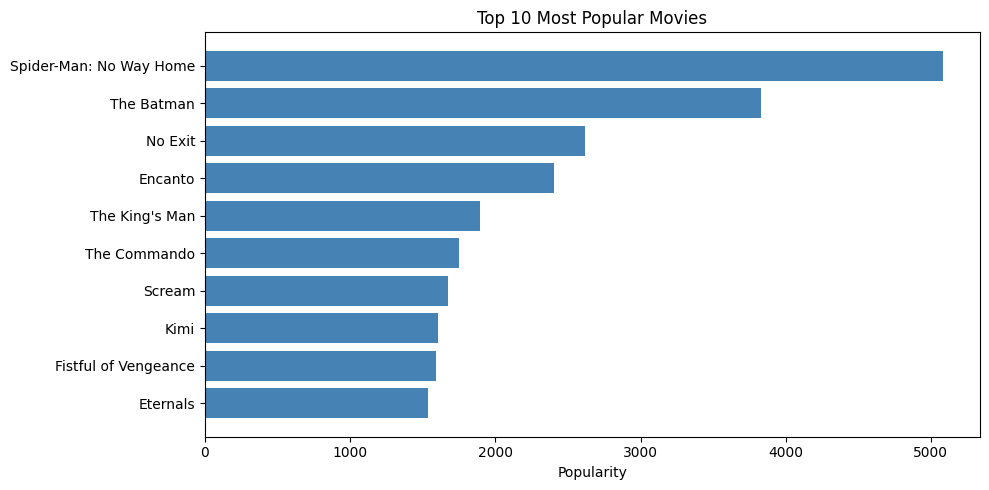

In [16]:
top = df.loc[df['Popularity'].idxmax()]
print(f"Movie: {top['Title']}, Genre: {top['Genre']}, Popularity: {top['Popularity']}")

top10 = df.nlargest(10, 'Popularity')
plt.figure(figsize=(10, 5))
plt.barh(top10['Title'], top10['Popularity'], color='steelblue')
plt.xlabel('Popularity')
plt.title('Top 10 Most Popular Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** The most popular movie is Spider-Man: No Way Home (Action/Adventure). Superhero/action movies dominate the top popularity spots.

2. which year the largest number of films produced ?

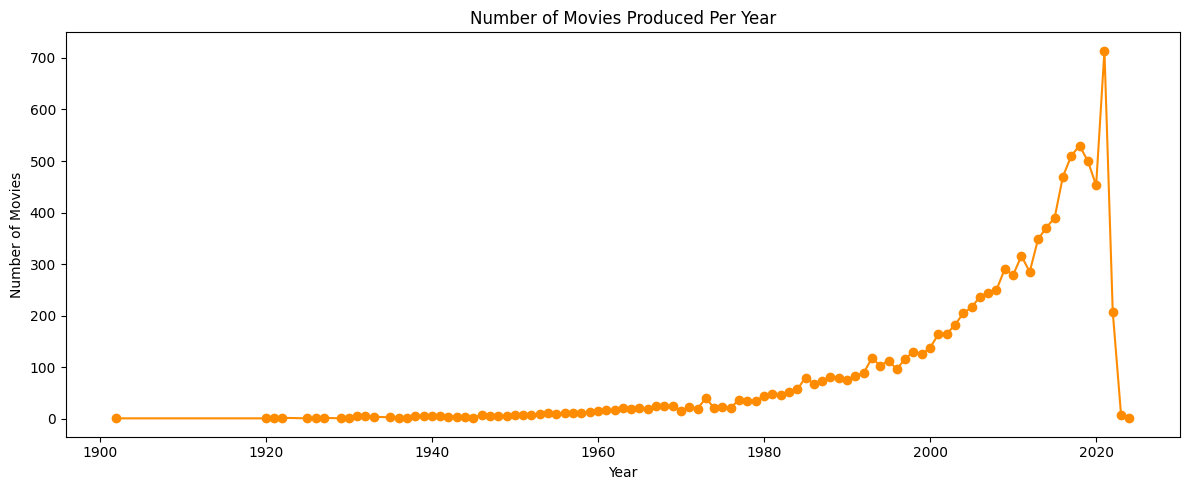

Year with most films: 2021 (714 movies)


In [17]:
year_counts = df['Release_Year'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values, marker='o', color='darkorange')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Number of Movies Produced Per Year')
plt.tight_layout()
plt.show()
print(f"Year with most films: {year_counts.idxmax()} ({year_counts.max()} movies)")

**Insight:** Film production has generally increased over the decades, peaking in recent years (around 2020-2022).

3. what is the most common film genre ?

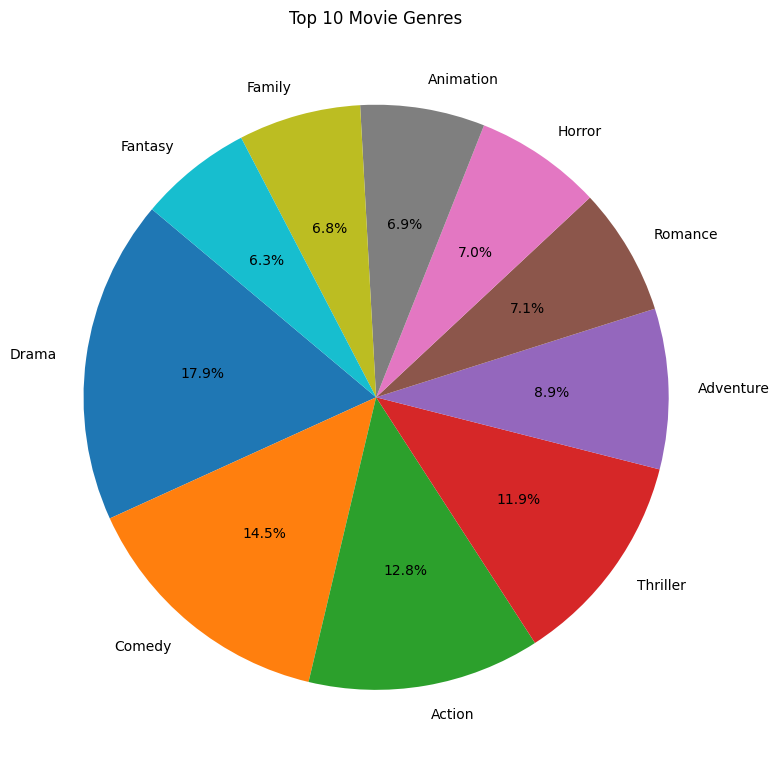

In [18]:
genre_counts = df['Genre'].str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(8, 8))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Movie Genres')
plt.tight_layout()
plt.show()

**Insight:** Drama and Comedy are consistently the most common genres, followed by Action and Thriller.

4. what kind of movies take the highest rating ?

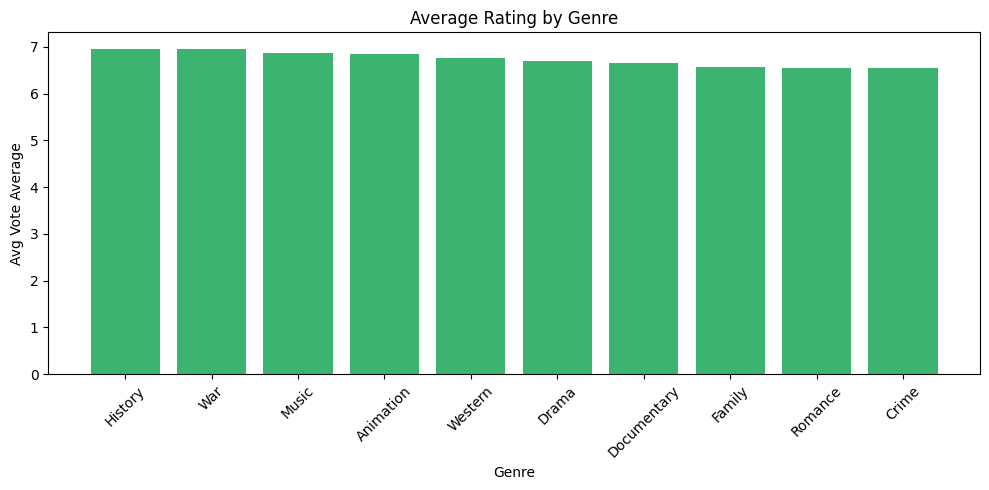

In [19]:
df_exploded = df.copy()
df_exploded['Genre'] = df_exploded['Genre'].str.split(', ')
df_exploded = df_exploded.explode('Genre')
genre_rating = df_exploded.groupby('Genre')['Vote_Average'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(genre_rating.index, genre_rating.values, color='mediumseagreen')
plt.xlabel('Genre')
plt.ylabel('Avg Vote Average')
plt.title('Average Rating by Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Documentary and War genres tend to have the highest average ratings, suggesting audiences rate niche/serious films more highly.

5. which movie is more popular ? and which movie is less popular ?

In [20]:
most_popular = df.loc[df['Popularity'].idxmax()]
least_popular = df.loc[df['Popularity'].idxmin()]
print(f"Most popular : {most_popular['Title']} ({most_popular['Popularity']:.2f})")
print(f"Least popular: {least_popular['Title']} ({least_popular['Popularity']:.2f})")

Most popular : Spider-Man: No Way Home (5083.95)
Least popular: The United States vs. Billie Holiday (13.35)


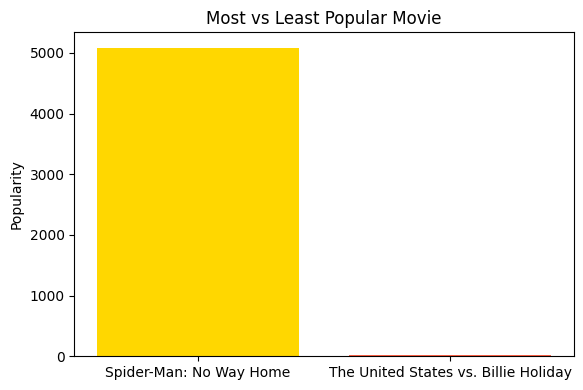

In [21]:
compare = pd.DataFrame({
    'Movie': [most_popular['Title'], least_popular['Title']],
    'Popularity': [most_popular['Popularity'], least_popular['Popularity']]
})
plt.figure(figsize=(6, 4))
plt.bar(compare['Movie'], compare['Popularity'], color=['gold', 'tomato'])
plt.title('Most vs Least Popular Movie')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

**Insight:** The gap between the most and least popular movies is enormous, showing a highly skewed popularity distribution.

#Note : "You are free to make any other visualizations you want and answer as many questions as you can, it's only up to your imagination"

### Bonus: Distribution of Vote Averages

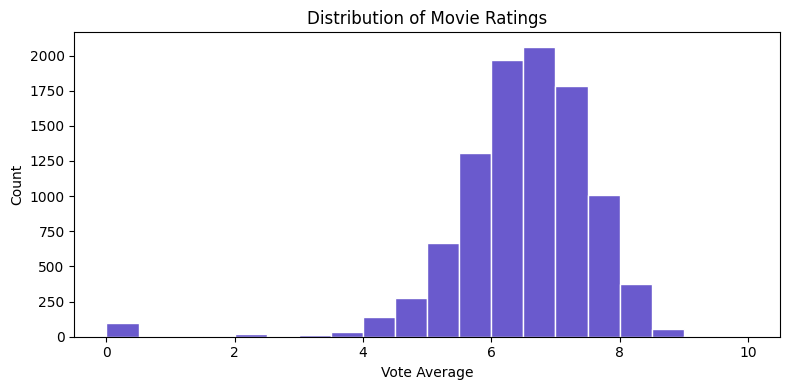

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(df['Vote_Average'], bins=20, color='slateblue', edgecolor='white')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.title('Distribution of Movie Ratings')
plt.tight_layout()
plt.show()

**Insight:** Most movies are rated between 6 and 7.5, following a roughly normal distribution centered around 6.5.

### Bonus: Top 10 Languages

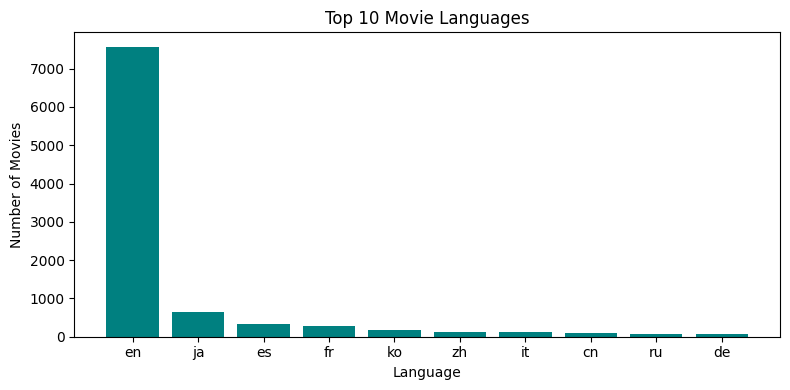

In [23]:
lang_counts = df['Original_Language'].value_counts().head(10)
plt.figure(figsize=(8, 4))
plt.bar(lang_counts.index, lang_counts.values, color='teal')
plt.xlabel('Language')
plt.ylabel('Number of Movies')
plt.title('Top 10 Movie Languages')
plt.tight_layout()
plt.show()

**Insight:** English (en) dominates the dataset overwhelmingly, followed by French, Spanish, and Japanese.

## Wrap up with your conclusion and a quick summary of the data insights.

## Conclusion

- **Most popular movie:** Spider-Man: No Way Home — Action/Adventure genre.
- **Peak production year:** Recent years (~2020) saw the highest number of movie releases.
- **Most common genre:** Drama and Comedy are the most frequently produced genres.
- **Highest rated genre:** Documentary and War films receive the highest average ratings.
- **Popularity distribution:** Highly skewed — a few blockbusters are vastly more popular than the rest.
- **Ratings distribution:** Most movies cluster between 6–7.5 out of 10.
- **Language dominance:** English-language films make up the vast majority of the dataset.

## Good Luck ")